# docs 页（集群抓取的概念知识正文）质量分析与清洗呈现

**这份数据是什么**：`lake_sync` 从采集集群 docs 线同步回湖的页面正文，落
`datasets/demiwtg/pages/<aa>/<page_sha>.md`。**URL 寻址**：`page_sha = sha256(url)`（不是内容哈希）——
它记的是「这条 URL 当次抓到什么」，同 URL 重抓内容会变，因此无法内容寻址复验。

**为什么要这本子**：docs 是概念的多模态知识载体（打标 kb、出题锚定、反幻觉都吃它）。
原始页是爬虫直出，混着站点外壳（导航菜单、电商商品 tile、反爬诱饵文本），必须先看清质量再用净版。

**口径（重要）**
- 原始页 = 同步产物，**只读不动**（AGENTS 2.1 精神：寻址店不手改）
- 净版 = `curation/clean_docs_pages.py` 产出，另存 `state/collect/docs_clean/`：
  `pages_clean.jsonl`（保留页 + 净正文 + 度量）/ `rejected.jsonl`（拒因审计，无正文）/
  `concept_docs.jsonl`（按概念聚合，与湖侧 docs 层同构 `{name, kind, body}`）/ `clean_report.json`
- 判定序：`short_raw` → `low_density` → `nav_listing` → `listing_page` → `html_noise` → `gibberish` → `duplicate` → **keep**
- **CJK 陷阱**：词数按「拉丁词 + 汉字数/2」折算。不折算的话中文整行只算 1 词，中文页会被系统性误杀（本版已修）

**怎么读**：C1 载入 → C2 盘点 → C3 质量分级 → C4 各类样例（原始 vs 净版）→ C5 域名诊断 → C6 单概念钻取 → C7 结论与建议

In [1]:
# C1 载入：页元数据索引（镜像清单）+ 净版/拒页/报告
import json, os, re, glob
from collections import Counter, defaultdict
from pathlib import Path
import pandas as pd

REPO = Path().resolve()
while not (REPO / "datasets" / "demiwtg").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
PAGES     = REPO / "datasets/demiwtg/pages"
CLEAN     = REPO / "state/collect/docs_clean"
MANIFESTS = REPO / "sync/manifests"
DRAFT     = REPO / "state/collect/concepts_docs_draft.jsonl"
BENCH     = REPO / "state/collect/concepts_batch_200.json"
print("REPO =", REPO)
assert PAGES.is_dir() and CLEAN.is_dir(), "pages/ 或 docs_clean/ 缺失：先跑 lake_sync 与 curation/clean_docs_pages.py"

def load_jsonl(p):
    out = []
    if not Path(p).exists():
        return out
    for line in open(p, encoding="utf-8"):
        line = line.strip()
        if not line:
            continue
        try:
            out.append(json.loads(line))
        except json.JSONDecodeError:
            pass
    return out

# 页元数据（跨节点同 sha 首见去重）
meta = {}
for f in sorted(glob.glob(f"{MANIFESTS}/*/docs*.jsonl")):
    node = os.path.basename(os.path.dirname(f))
    for r in load_jsonl(f):
        p = r.get("path")
        if isinstance(p, str) and p.startswith("pages/"):
            sha = r.get("page_sha") or p.rsplit("/", 1)[-1].split(".")[0]
            meta.setdefault(sha, {k: r.get(k) for k in
                ("url", "authority", "title", "n_passages", "n_images", "query", "fetched_at")}
                | {"concepts": list(r.get("concepts") or []), "node": node})

clean_df = pd.DataFrame(load_jsonl(CLEAN / "pages_clean.jsonl"))
rej_df   = pd.DataFrame(load_jsonl(CLEAN / "rejected.jsonl"))
report   = json.loads((CLEAN / "clean_report.json").read_text(encoding="utf-8"))
print(f"原始页 {report['input_pages']:,} | 净页 {len(clean_df):,} | 拒页 {len(rej_df):,} | 元数据在册 {len(meta):,}")

def raw_text(sha, limit=200_000):
    g = glob.glob(f"{PAGES}/{sha[:2]}/{sha}.*")
    return open(g[0], encoding="utf-8", errors="replace").read(limit) if g else ""
print("可用列（净页）:", list(clean_df.columns))

REPO = /yzp/zhaozy/yangzepeng/0905/demiwtg
原始页 10,020 | 净页 4,326 | 拒页 5,694 | 元数据在册 10,020
可用列（净页）: ['page_sha', 'authority', 'url', 'title', 'domain', 'concepts', 'n_passages', 'n_images', 'query', 'fetched_at', 'lang', 'chars_raw', 'chars_clean', 'dense_tokens', 'cjk_ratio', 'common_en_ratio', 'prose_frac', 'enders_per_1k', 'n_lines', 'prose_mode', 'prose_lines', 'prose_chars', 'prose_line_frac', 'commerce_frac', 'text']


## C2 盘点：规模、来源、语言、每概念页数、度量分布

看点：净版相对原始页压缩了多少（站点外壳占比）、覆盖多少概念、语言构成，以及
`prose_line_frac`（散文行占比）/`commerce_frac`（商品 tile 占比）两个质量度量的分布。

In [2]:
raw_bytes = sum(os.path.getsize(p)
                for d in os.listdir(PAGES) if (PAGES / d).is_dir()
                for p in (PAGES / d).iterdir())
rows = [
    ("原始页 datasets/demiwtg/pages", report["input_pages"], f"{raw_bytes/1e6:.0f} MB", "同步产物，只读"),
    ("净版 pages_clean.jsonl", len(clean_df), f"{int(clean_df['chars_clean'].sum())/1e6:.1f} M 字",
     f"中位 {int(clean_df['chars_clean'].median()):,} 字/页"),
    ("按概念聚合 concept_docs.jsonl", report["concept_docs"], f"{os.path.getsize(CLEAN/'concept_docs.jsonl')/1e6:.1f} MB",
     f"bench283 覆盖 {report['bench283_covered']}/{report['bench283_total']}"),
    ("拒页 rejected.jsonl", len(rej_df), f"{os.path.getsize(CLEAN/'rejected.jsonl')/1e6:.1f} MB", "元数据+拒因，无正文"),
]
print(pd.DataFrame(rows, columns=["产物", "条数", "体量", "备注"]).to_string(index=False))
print(f"\n压缩：原始 {report['chars_raw_total']/1e6:.1f}M 字 → 净 {report['chars_clean_total']/1e6:.1f}M 字"
      f"（外壳占 {(1-report['chars_clean_total']/report['chars_raw_total'])*100:.0f}%）")
print("authority:", clean_df["authority"].value_counts().to_dict(),
      "| lang:", clean_df["lang"].value_counts().to_dict(),
      "| prose_mode 命中:", int(clean_df["prose_mode"].sum()))

per = Counter(c for cs in clean_df["concepts"] for c in cs)
s = pd.Series(list(per.values()))
print(f"\n每概念净页数：覆盖 {len(per)} 概念 | 中位 {s.median():.0f} | p90 {s.quantile(.9):.0f} | "
      f"最多 {s.max()} | 仅 1 页的概念 {int((s==1).sum())} 个")
print("\n度量分布：")
print(clean_df[["chars_raw", "chars_clean", "n_lines", "prose_line_frac",
                "commerce_frac", "cjk_ratio", "enders_per_1k"]].describe().round(3).to_string())

                        产物    条数       体量                  备注
原始页 datasets/demiwtg/pages 10020   204 MB             同步产物，只读
      净版 pages_clean.jsonl  4326 31.0 M 字        中位 2,831 字/页
  按概念聚合 concept_docs.jsonl   272   3.8 MB bench283 覆盖 272/283
         拒页 rejected.jsonl  5694   3.3 MB          元数据+拒因，无正文

压缩：原始 150.9M 字 → 净 31.0M 字（外壳占 79%）
authority: {'serp': 3083, 'wiki': 1243} | lang: {'en': 2634, 'zh': 1692} | prose_mode 命中: 3271

每概念净页数：覆盖 272 概念 | 中位 14 | p90 31 | 最多 56 | 仅 1 页的概念 5 个

度量分布：
        chars_raw  chars_clean   n_lines  prose_line_frac  commerce_frac  cjk_ratio  enders_per_1k
count    4326.000     4326.000  4326.000         4326.000       4326.000   4326.000       4326.000
mean    34885.584     7160.173    50.251            0.183          0.017      0.257         15.951
std     57952.224    13083.252    72.452            0.183          0.042      0.340         10.733
min       303.000      300.000     1.000            0.000          0.000      0.000          0.00

## C3 质量分级：拒因分布与来源交叉

`wiki` 线（结构化源）与 `serp` 线（搜索引擎抓站）的可用率差异是本节核心结论。

authority × 判定：
             总页  duplicate  gibberish  html_noise  listing_page  low_density  nav_listing  short_raw  keep  keep率%
authority                                                                                                         
serp       8725        537       2279          58            26          595           97       2050  3083    35.3
wiki       1295          0          1           0            12           36            1          2  1243    96.0


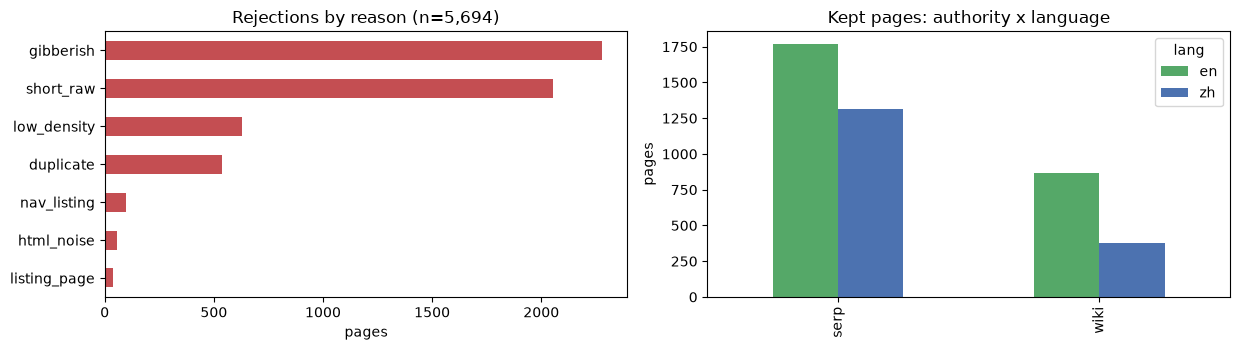


各拒因一句话：
  short_raw   原始正文 <200 字（JS 壳站/抓取失败）
  gibberish   无中文且常用英文词占比 <6%（反爬诱饵填充文本）
  low_density 净文实词 token <40（抽完外壳没内容）
  duplicate   内容 sha 与已收页重复（同文多 URL；按 authority 优先留一）
  nav_listing 纯导航菜单（净文 <300 字或散文行占比 <2%）
  listing_page 电商商品 tile 占比 ≥30%
  html_noise  HTML 骨架标记 ≥10 且实词 <200


In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

cross = pd.crosstab(rej_df["authority"], rej_df["reason"])
keep_by_auth = clean_df["authority"].value_counts().rename("keep")
tbl = cross.join(keep_by_auth, how="outer").fillna(0).astype(int)
tot = tbl.sum(axis=1)
tbl.insert(0, "总页", tot)
tbl["keep率%"] = (tbl["keep"] / tot * 100).round(1)
print("authority × 判定：")
print(tbl.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.6))
rej_df["reason"].value_counts().sort_values().plot.barh(ax=axes[0], color="#c44e52")
axes[0].set_title(f"Rejections by reason (n={len(rej_df):,})")
axes[0].set_xlabel("pages"); axes[0].set_ylabel("")
pd.crosstab(clean_df["authority"], clean_df["lang"]).plot.bar(
    ax=axes[1], color=["#55a868", "#4c72b0", "#dd8452"])
axes[1].set_title("Kept pages: authority x language")
axes[1].set_ylabel("pages"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()

print("\n各拒因一句话：")
print("  short_raw   原始正文 <200 字（JS 壳站/抓取失败）")
print("  gibberish   无中文且常用英文词占比 <6%（反爬诱饵填充文本）")
print("  low_density 净文实词 token <40（抽完外壳没内容）")
print("  duplicate   内容 sha 与已收页重复（同文多 URL；按 authority 优先留一）")
print("  nav_listing 纯导航菜单（净文 <300 字或散文行占比 <2%）")
print("  listing_page 电商商品 tile 占比 ≥30%")
print("  html_noise  HTML 骨架标记 ≥10 且实词 <200")

## C4 样例：每类到底长什么样（原始 vs 净版）

这一节回答「docs 是什么样的」。每类抽 1 页：wiki 中文/英文净页、serp 净页、
`gibberish`/`short_raw`/`listing_page` 三类典型拒页。

In [4]:
def show_page(sha, tag, row=None):
    m = meta.get(sha, {})
    print("=" * 90)
    print(f"[{tag}] {str(m.get('title',''))[:60]} | {m.get('authority')} | 概念 {(m.get('concepts') or [])[:3]}")
    print(f"  url: {str(m.get('url',''))[:120]}")
    raw = raw_text(sha)
    print(f"  原始 {len(raw):,} 字，前 420 字：")
    print("   ", raw[:420].replace("\n", " ┃ "))
    if row is not None:
        print(f"  净版 {row['chars_clean']:,} 字（散文行占比 {row['prose_line_frac']}，"
              f"商品占比 {row['commerce_frac']}，prose_mode={row['prose_mode']}），前 620 字：")
        print("   ", row["text"][:620].replace("\n", " ┃ "))

picks = []
for tag, mask in [("wiki-zh 保留", (clean_df.lang == "zh") & (clean_df.authority == "wiki")),
                  ("wiki-en 保留", (clean_df.lang == "en") & (clean_df.authority == "wiki")),
                  ("serp 保留", clean_df.authority == "serp")]:
    sub = clean_df[mask]
    if len(sub):
        r = sub.sort_values("chars_clean", ascending=False).iloc[0]
        picks.append((tag, r["page_sha"], r))
for reason in ("gibberish", "short_raw", "listing_page"):
    sub = rej_df[rej_df.reason == reason]
    if len(sub):
        picks.append((f"拒:{reason}", sub.iloc[0]["page_sha"], None))
for tag, sha, row in picks:
    show_page(sha, tag, row)

[wiki-zh 保留] 尼古拉·特斯拉 | wiki | 概念 ['特斯拉']
  url: https://zh.wikipedia.org/wiki/尼古拉·特斯拉
  原始 200,000 字，前 420 字：
    [跳转到内容](https://zh.wikipedia.org/wiki/%E5%B0%BC%E5%8F%A4%E6%8B%89%C2%B7%E7%89%B9%E6%96%AF%E6%8B%89#bodyContent) ┃ 主菜单 ┃ 主菜单 ┃ 移至侧栏 隐藏 ┃ 导航  ┃   * [首页](https://zh.wikipedia.org/wiki/Wikipedia:%E9%A6%96%E9%A1%B5 "访问首页​\[alt-z\]") ┃   * [分类索引](https://zh.wikipedia.org/wiki/Wikipedia:%E5%88%86%E7%B1%BB%E7%B4%A2%E5%BC%95 "以分类索引搜寻中文维基百科") ┃   * [特色内容](https://zh.wikipedia.org/wiki/Portal:%E7%89%B9%E8%89%B2%E5%85%A7%E5%AE%B9 "查看中文维基百科的特色
  净版 50,211 字（散文行占比 0.2283，商品占比 0.0292，prose_mode=True），前 620 字：
    坐标： 44°48′18″N 20°28′15″E﻿ / ﻿44.8051°N 20.4707°E﻿ / 44.8051; 20.4707 ┃ 44°48′18″N 20°28′15″E﻿ / ﻿44.8051°N 20.4707°E﻿ / 44.8051; 20.4707 ┃ 特斯拉在奥地利帝国出生与成长，在19世纪70年代学习工程学和物理学，没有获得学位。19世纪80年代初，在新的电力行业背景下，特斯拉在大陆爱迪生公司研究电话通信（英语：Telephony）领域，并在此期间取得实践经验。1884年，特斯拉移民到美国，加入美国国籍，成为一名归化美国公民，之后在纽约市的爱迪生机械厂（英语：Edison Machine Works）工作过很短的一段时间，随后自立门户。在合作伙伴的帮助下，特斯拉在纽约建立自己的实验室和公司，以开发一系列的电器和机械装置，在此

## C5 域名诊断：哪些源该留、哪些该在采集端拉黑

按域名统计 keep 率：低 keep 率 + 大页量 = 采集端最该治理的源（或加正文抽取、或换 headless、或拉黑）。

In [5]:
dom = defaultdict(Counter)
for r in clean_df.itertuples():
    dom[r.domain]["keep"] += 1
for r in rej_df.itertuples():
    d = re.sub(r"^https?://", "", str(getattr(r, "url", "") or "?")).split("/")[0]
    dom[d][getattr(r, "reason")] += 1
rows = [(d, sum(c.values()), c.get("keep", 0),
         round(c.get("keep", 0) / max(1, sum(c.values())) * 100, 1), dict(c))
        for d, c in dom.items()]
ddf = pd.DataFrame(rows, columns=["domain", "总页", "keep", "keep率%", "明细"])
print("页量最多的 12 个域名：")
print(ddf.sort_values("总页", ascending=False).head(12).to_string(index=False))
print("\nkeep 率最低（≥20 页）——采集端治理清单：")
big = ddf[ddf["总页"] >= 20].sort_values("keep率%")
print(big.head(8).to_string(index=False))
print(f"\n治理收益估算：这 8 个域名共 {int(big.head(8)['总页'].sum()):,} 页，"
      f"若采集端直接不抓，可省 {int(big.head(8)['总页'].sum())/report['input_pages']*100:.0f}% 抓取量")

页量最多的 12 个域名：
                domain  总页  keep  keep率%                                                                                                    明细
      en.wikipedia.org 994   971    97.7                 {'keep': 971, 'listing_page': 13, 'low_density': 6, 'nav_listing': 1, 'duplicate': 3}
      zh.wikipedia.org 735   663    90.2 {'keep': 663, 'listing_page': 4, 'low_density': 33, 'duplicate': 24, 'short_raw': 10, 'gibberish': 1}
       baike.baidu.com 388   277    71.4                                                     {'keep': 277, 'short_raw': 92, 'low_density': 19}
     www.microsoft.com 338    11     3.3                                     {'keep': 11, 'short_raw': 244, 'duplicate': 82, 'low_density': 1}
www.royalcaribbean.com 263    31    11.8                                    {'keep': 31, 'short_raw': 114, 'duplicate': 99, 'low_density': 19}
          www.etsy.com 203    71    35.0                                                      {'keep': 71, 'short_raw': 129, 'lo

## C6 单概念钻取：一个概念的 docs 到底给了什么

`CONCEPT = None` 时自动取净页最多的概念；改成任意概念名（如 `"软银 NAO"`、`"绞胎瓷"`）可钻取。
末尾对比湖侧既有 docs 草稿（2026-09-07 从 `desc` 退役迁来的摘要层），看两种知识形态的差别。

In [6]:
CONCEPT = None                      # 例：CONCEPT = "软银 NAO"
per = Counter(c for cs in clean_df["concepts"] for c in cs)
CONCEPT = CONCEPT or per.most_common(1)[0][0]
n_raw = sum(1 for m in meta.values() if CONCEPT in (m.get("concepts") or []))
rows = clean_df[clean_df["concepts"].apply(lambda cs: CONCEPT in cs)].sort_values(
    "chars_clean", ascending=False)
print(f"概念「{CONCEPT}」：原始页 {n_raw} → 净页 {len(rows)}")
if len(rows):
    print(rows[["authority", "domain", "title", "chars_raw", "chars_clean",
                "prose_line_frac", "lang"]].head(12).to_string(index=False))
    print("\n--- 最长一页净文，前 900 字 ---")
    print(rows.iloc[0]["text"][:900])

cd = next((c for c in load_jsonl(CLEAN / "concept_docs.jsonl") if c["name"] == CONCEPT), None)
if cd:
    print(f"\n--- concept_docs 聚合（{cd['n_pages']} 页 / body {len(cd['body']):,} 字），前 1,200 字 ---")
    print(cd["body"][:1200])
    print("sources:", [(s["authority"], s["chars"]) for s in cd["sources"]])
else:
    rej_reasons = Counter(x["reason"] for x in load_jsonl(CLEAN / "rejected.jsonl")
                          if CONCEPT in (x.get("concepts") or []))
    print(f"\n该概念无净版聚合页；拒因分布 {dict(rej_reasons)}")

draft = next((r for r in load_jsonl(DRAFT) if r.get("name") == CONCEPT), None)
print("\n--- 湖侧 docs 草稿（desc 退役迁移来的摘要层）同概念条目 ---")
if draft:
    print(f"kind={draft.get('kind')} | {len(draft.get('body',''))} 字 | 首 240 字：")
    print(" ", draft.get("body", "")[:240])
else:
    print("（草稿无此概念）")

概念「新加坡」：原始页 108 → 净页 56
authority             domain                                            title  chars_raw  chars_clean  prose_line_frac lang
     serp en.m.wikipedia.org                            Singapore - Wikipedia     634304       156342           0.3079   en
     wiki   en.wikipedia.org                                        Singapore     634296       156342           0.3075   en
     serp   en.wikipedia.org                                    Stargate SG-1      60434        54689           0.5981   en
     wiki   en.wikipedia.org                       Republic of Singapore Navy      40957        37146           0.4903   en
     wiki   en.wikipedia.org                             Economy of Singapore      43057        32328           0.3642   en
     serp    baike.baidu.com                                 新加坡（新加坡共和国）_百度百科     133885        31437           0.1848   zh
     serp   en.wikipedia.org History of the Republic of Singapore - Wikipedia      97552        31285       

## C7 结论与建议

**结论（本轮数据）**
1. **净版可用率 43%**（10,020 页 → 4,326 页），但分源差异悬殊：`wiki` 线约 96% 可用，
   `serp` 线约 34%。serp 抓站质量是主要短板。
2. 原始页里 **约 80% 字节是站点外壳**（导航/商品 tile/侧栏），净版把 150.9M 字压到 31.0M 字。
3. 拒因两大头：`gibberish` 2,280（反爬诱饵填充，分散在小域名）与 `short_raw` 2,052
   （JS 壳站抓到空壳，如 microsoft.com 327 / baike.so.com 173 / ai.so.com 110）。
   这两类合占拒页 75%，都是**采集端可避免的浪费**。
4. bench283 概念净版覆盖 **272/283**（11 个概念原始页全被拒，多为 text-only 后果类概念）。
5. 中文页在 v1 规则下会被系统性误杀（词数按空白分词），已按「汉字数/2」折算修复；
   当前净页中文 1,692 / 英文 2,634。

**建议（按性价比排序）**
1. **采集端加正文抽取再落盘**：docs 线抓页后先做 readability 级抽取 + 散文行占比门禁，
   不达标不存 pages——可直接砍掉 57% 的存储与传输，并让湖侧不必再清洗。
2. **JS 壳站换 headless 或拉黑**：短页大户（microsoft/baike.so/ai.so 等）用现成 playwright
   渲染，或直接从 SERP 白名单剔除。集群 HANDOVER 提到 playwright 已可用。
3. **反爬诱饵识别前置**：gibberish 判据（无 CJK 且常用英文词占比 <6%）成本极低，
   放采集端做同样有效，避免把诱饵当知识存下来。
4. **净版消费路径**：`concept_docs.jsonl` 已是湖侧 docs 层同构 schema，建议**与摘要层并存**
   （`kind="passages"` vs 现有 `kind="summary"`），不要覆盖 52,980 条摘要草稿——
   摘要是压缩知识、passages 是可引用原文，打标/出题用途不同。
5. **未覆盖的维度**：页内图片（`n_images` 有计数但图不随 docs 线来）、跨语言重复、
   新鲜度（`fetched_at`）。若要做 multimodal 知识，图片线需单独打通。